# STAT201 · 3-hafta · Kompyuter laboratoriyasi (Python)

### Shartli ehtimollik, toʻliq ehtimollik formulasi va Bayes teoremasi

**Toshkent Xalqaro Universiteti · Iqtisodiyot fakulteti · 2025/2026**

---

**Maqsad.** Maʼruzada keltirib chiqarilgan **toʻliq ehtimollik formulasi**
va **Bayes teoremasi**ni haqiqiy maʼlumot ustida **tekshirish**, soʻng
ularni bevosita sanash imkoni *boʻlmagan* masalalarga (diagnostik test,
kredit skoring) qoʻllash.

**Haftaning markaziy gʻoyasi — formulaga ishonchni qozonish.**
Bayes teoremasini biz avval *javob mustaqil ravishda maʼlum boʻlgan*
joyda sinaymiz: kino maʼlumotida $\Pr(\text{Horror} \mid R)$ ni ham
formula bilan, ham $154/1113$ deb **sanab** olamiz. Ikkalasi *aynan* bir
xil chiqishi shart — yaxlitlash xatosi ham boʻlmasligi kerak. Faqat
shundan keyin biz formulani skrining testiga qoʻllaymiz, u yerda esa
sanash mumkin emas: kimning kasal ekanini bilmaymiz.

> **Qoida.** Formulaga u *tasdiqlangani* uchun ishoning, u *aytilgani*
> uchun emas.

**Ish zanjiri.** Har bir topshiriqda quyidagi ketma-ketlikni yozma
ravishda bajarasiz:

> **statistik tushuncha → maʼlumot → kod → natija → talqin → qaror**

Faqat kod yozib, natijani izohsiz qoldirish — topshiriq bajarilmagan
hisoblanadi. Baholashning yarmidan koʻpi aynan *talqin* va *qaror*
bosqichlariga beriladi.

**Vaqt va ball taqsimoti (120 daqiqa, 115 ball + 5 bonus).**

| # | Mazmun | Daqiqa | Blum | Ball |
|---|---|---|---|---|
| 0 | Muhitni sozlash | 5 | — | — |
| 1 | Boʻlinma va toʻliq ehtimollik formulasi | 20 | Qoʻllash | 20 |
| 2 | Qayta ishlatiladigan Bayes funksiyasi | 25 | Tahlil | 25 |
| 3 | Skrining testi kalkulyatori va PPV egri chizigʻi | 25 | Tahlil | 25 |
| 4 | Monty Hall simulyatsiyasi | 25 | Baholash | 25 |
| 5 | Bazaviy stavkani oʻzgartirish | 20 | Baholash | 20 |
| 6 | Ixtiyoriy: hosildorlik maʼlumotida Bayes | uyda | Yaratish | +5 |

**Oldingi bilim (2-hafta).** Hodisani **mantiqiy (boolean) seriya**
sifatida ifodalash (`A.sum()` $= n(A)$, `A.mean()` $= \Pr(A)$); qoʻshish
qoidasi; shartli ehtimollik taʼrifi; koʻpaytirish qoidasi; MINSTD
generatori.

> **Bu daftar R varianti bilan AYNAN bir xil sonlarni beradi** —
> simulyatsiya natijalari ham. Buni oxirgi «Yakuniy nazorat roʻyxati»
> boʻlimi tasdiqlaydi.

## 0-bosqich. Muhitni sozlash

In [1]:
# --- Kerakli kutubxonalar --------------------------------------------
# pandas     — jadval koʻrinishidagi maʼlumot (DataFrame)
# numpy      — sonli massivlar va vektor amallari
# matplotlib — grafiklar
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print("pandas", pd.__version__, "| numpy", np.__version__,
      "| matplotlib", matplotlib.__version__)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

%matplotlib inline

pandas 3.0.2 | numpy 2.4.4 | matplotlib 3.10.9


In [2]:
# --- Grafiklarda oʻzbekcha «ʻ» belgisi (U+02BB) ----------------------
# matplotlib matnni tanlangan shrift bilan chizadi. Agar shriftda U+02BB
# glifi boʻlmasa, uning oʻrnida QUTICHA (□) chiqadi va «Glyph 699 ...
# missing from font(s)» ogohlantirishi beriladi.
plt.rcParams["font.family"] = "DejaVu Sans"   # U+02BB bu shriftda BOR
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.30

# QOIDA (2-haftadan): grafik yorliqlarida faqat ASCII harflar —
# shunda natija har qanday muhitda, jumladan R ning standart pdf()
# qurilmasida ham, buzilmaydi.

# --- Okabe-Ito palitrasi (rang koʻrmaslikka moslashgan) ---------------
oiBlue, oiOrange, oiGreen = "#0072B2", "#E69F00", "#009E73"
oiPink, oiVerm,   oiSky   = "#CC79A7", "#D55E00", "#56B4E9"

In [3]:
# --- Asosiy maʼlumot va ISHCHI FAZO -----------------------------------
# 2-haftadagi qaror oʻzgarmaydi: reytingi koʻrsatilmagan 9 ta film
# fazodan chiqariladi, chunki ular uchun «R reyting» hodisasi
# aniqlanmagan. |S| = 2458.
kino = pd.read_csv("data/kinolar-byudjet.csv", encoding="utf-8")
kino_t = kino.dropna(subset=["reyting"]).copy()
n = len(kino_t)

print("xom satrlar         :", len(kino))
print("reytingi yoʻq       :", len(kino) - n)
print("ISHCHI FAZO |S| = n :", n)

# Kontingensiya jadvali — butun laboratoriyaning asosi.
jadval = pd.crosstab(kino_t["janr"], kino_t["reyting"],
                     margins=True, margins_name="Jami")
print(jadval.to_string())

xom satrlar         : 2467
reytingi yoʻq       : 9
ISHCHI FAZO |S| = n : 2458
reyting     G   PG  PG-13     R  Jami
janr                                 
Action      0    6    178   174   358
Adventure  41  246     62    14   363
Comedy      3   39    266   292   600
Drama       5  106    339   479   929
Horror      0    3     51   154   208
Jami       49  400    896  1113  2458


---
## 1-topshiriq. Boʻlinma va toʻliq ehtimollik formulasi

**Qiyinlik: 3 (Amaliy) · Blum: Qoʻllash · 20 ball · 20 daqiqa**

### Statistik tushuncha

**Boʻlinma** *(partition)*. $B_1, B_2, \dots, B_k$ hodisalari $S$ ning
boʻlinmasi deyiladi, agar

1. ular juft-juft kesishmasa: $B_i \cap B_j = \varnothing$ ($i \ne j$),
2. birlashmasi butun fazo boʻlsa: $\bigcup_{i=1}^{k} B_i = S$.

Yaʼni **har bir natija aynan bitta** $B_i$ ga tushadi.

**Toʻliq ehtimollik formulasi** *(law of total probability)*: agar
$B_1,\dots,B_k$ boʻlinma boʻlsa va $\Pr(B_i) > 0$ boʻlsa, ixtiyoriy $A$
uchun

$$\Pr(A) \;=\; \sum_{i=1}^{k} \Pr(A \mid B_i)\,\Pr(B_i).$$

*Isboti bir qatorlik:* $A = \bigcup_i (A \cap B_i)$ va bu boʻlaklar
kesishmaydi, demak A3 aksiomasi boʻyicha ehtimolliklar qoʻshiladi; har
bir hadga koʻpaytirish qoidasini qoʻllaymiz.

**Bugungi tekshiruv.** $\Pr(R)$ ni **ikki mustaqil yoʻl** bilan olamiz:
(a) formula orqali, janrlar boʻlinmasidan; (b) bevosita sanab,
$1113/2458$. Ular *aynan* teng chiqishi shart.

### Maʼlumot

`data/kinolar-byudjet.csv`, ishchi fazo $n = 2\,458$. Boʻlinma — beshta
janr. Hodisa $A = R$ («film R reyting oldi»).

In [4]:
# --- 1-qadam: BOʻLINMA ekanini TEKSHIRISH ------------------------------
# Formula boʻlinmaga tayanadi. Shu sababli birinchi qadam — tekshirish,
# qoʻllash emas.
janrlar = sorted(kino_t["janr"].unique())     # alifbo tartibida — barqaror
print("janrlar:", ", ".join(janrlar), "\n")

# (1) Har bir film aynan BITTA janrga tegishlimi?
janr_sonlari = np.array([int((kino_t["janr"] == g).sum()) for g in janrlar])
print("janrlar boʻyicha sonlar:", janr_sonlari)
print("yigʻindi =", janr_sonlari.sum(), " | n =", n,
      " | boʻlinma:", janr_sonlari.sum() == n)

# (2) Ehtimolliklar yigʻindisi 1 ga tengmi?
P_janr = janr_sonlari / n
print("P(B_i) yigʻindisi = %.10f" % P_janr.sum())

janrlar: Action, Adventure, Comedy, Drama, Horror 

janrlar boʻyicha sonlar: [358 363 600 929 208]
yigʻindi = 2458  | n = 2458  | boʻlinma: True
P(B_i) yigʻindisi = 1.0000000000


In [5]:
# --- 2-qadam: toʻliq ehtimollik formulasining JADVALI -------------------
R = kino_t["reyting"] == "R"          # hodisa = mantiqiy (boolean) seriya

ltp = pd.DataFrame({
    "janr": janrlar,
    "n_B":  janr_sonlari,
    "P_B":  P_janr,
    "n_RB": [int(((kino_t["janr"] == g) & R).sum()) for g in janrlar],
})
ltp["P_R_B"] = ltp["n_RB"] / ltp["n_B"]        # ishonchlilik P(R|B)
ltp["hissa"] = ltp["P_R_B"] * ltp["P_B"]       # formulaning bitta hadi

print(ltp.to_string(index=False,
                    float_format=lambda v: f"{v:.5f}"))

     janr  n_B     P_B  n_RB   P_R_B   hissa
   Action  358 0.14565   174 0.48603 0.07079
Adventure  363 0.14768    14 0.03857 0.00570
   Comedy  600 0.24410   292 0.48667 0.11880
    Drama  929 0.37795   479 0.51561 0.19487
   Horror  208 0.08462   154 0.74038 0.06265


In [6]:
# --- 3-qadam: IKKI YOʻL BILAN P(R) --------------------------------------
P_R_formula  = ltp["hissa"].sum()     # toʻliq ehtimollik formulasi
P_R_bevosita = R.mean()               # bevosita sanash: n(R)/n

print("toʻliq ehtimollik formulasi : P(R) = %.10f" % P_R_formula)
print("bevosita sanash             : P(R) = %d/%d = %.10f"
      % (R.sum(), n, P_R_bevosita))
print("farq                        : %.3e" % abs(P_R_formula - P_R_bevosita))
print("aynan teng (yaxlitlashsiz):", P_R_formula == P_R_bevosita)

toʻliq ehtimollik formulasi : P(R) = 0.4528071603
bevosita sanash             : P(R) = 1113/2458 = 0.4528071603
farq                        : 0.000e+00
aynan teng (yaxlitlashsiz): True


In [7]:
# --- 4-qadam: BOʻLINMA BUZILSA nima boʻladi? ---------------------------
# (a) Toʻliq boʻlmagan toʻplam: Horror ni tashlab yuboramiz.
kam = ltp[ltp["janr"] != "Horror"]
print("(a) Horror tashlansa: P(B) yigʻindisi = %.4f (1 emas!)"
      % kam["P_B"].sum())
print("    formula beradi: %.4f, haqiqiy P(R) = %.4f, xato = %.4f"
      % (kam["hissa"].sum(), P_R_bevosita,
         P_R_bevosita - kam["hissa"].sum()))

# (b) Kesishuvchi «boʻlinma»: D = Drama, K = katta byudjetli.
D = kino_t["janr"] == "Drama"
K = kino_t["byudjet"] > kino_t["byudjet"].median()
print("(b) D va K kesishmasi: n(D va K) = %d  (0 boʻlishi kerak edi)"
      % (D & K).sum())
soxta = R[D].mean() * D.mean() + R[K].mean() * K.mean()
print("    «formula» beradi: %.4f, haqiqiy P(R) = %.4f"
      % (soxta, P_R_bevosita))
print("    Xulosa: shartlarni tekshirmasdan qoʻllangan formula xato "
      "javob beradi va HECH QANDAY ogohlantirish bermaydi.")

(a) Horror tashlansa: P(B) yigʻindisi = 0.9154 (1 emas!)
    formula beradi: 0.3902, haqiqiy P(R) = 0.4528, xato = 0.0627
(b) D va K kesishmasi: n(D va K) = 316  (0 boʻlishi kerak edi)
    «formula» beradi: 0.3568, haqiqiy P(R) = 0.4528
    Xulosa: shartlarni tekshirmasdan qoʻllangan formula xato javob beradi va HECH QANDAY ogohlantirish bermaydi.


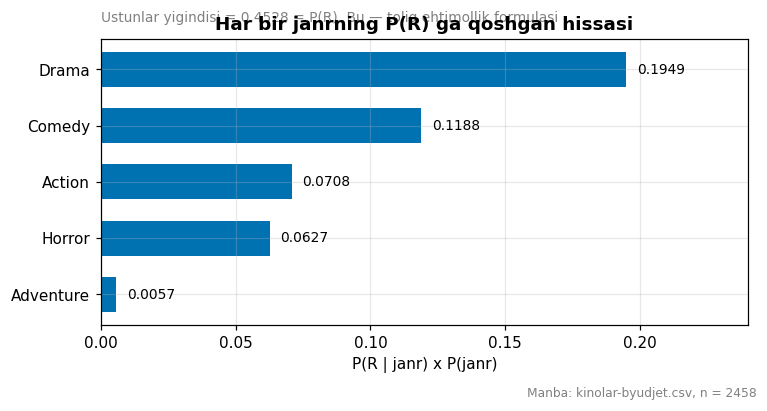

In [8]:
# --- 5-qadam: formulani KOʻRSATISH -------------------------------------
# Har bir janrning P(R) ga qoʻshgan hissasi. Yorliqlar ASCII.
gr = ltp.sort_values("hissa")
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(gr["janr"], gr["hissa"], color=oiBlue, height=0.62)
for y, v in zip(range(len(gr)), gr["hissa"]):
    ax.text(v + 0.004, y, f"{v:.4f}", va="center", fontsize=9)
ax.set_xlim(0, 0.24)
ax.set_xlabel("P(R | janr) x P(janr)")
ax.set_title("Har bir janrning P(R) ga qoshgan hissasi", fontweight="bold")
ax.text(0, 1.06, "Ustunlar yigindisi = 0.4528 = P(R). Bu — toliq ehtimollik formulasi",
        transform=ax.transAxes, fontsize=9, color="grey")
fig.text(0.99, -0.02, "Manba: kinolar-byudjet.csv, n = 2458",
         ha="right", fontsize=8, color="grey")
plt.tight_layout()
plt.show()

### Natija (kutilayotgan)

```
janrlar boʻyicha sonlar: [358 363 600 929 208]
yigʻindi = 2458  | n = 2458  | boʻlinma: True
P(B_i) yigʻindisi = 1.0000000000

     janr  n_B     P_B  n_RB   P_R_B   hissa
   Action  358 0.14565   174 0.48603 0.07079
Adventure  363 0.14768    14 0.03857 0.00570
   Comedy  600 0.24410   292 0.48667 0.11880
    Drama  929 0.37795   479 0.51561 0.19487
   Horror  208 0.08462   154 0.74038 0.06265

toʻliq ehtimollik formulasi : P(R) = 0.4528071603
bevosita sanash             : P(R) = 1113/2458 = 0.4528071603
farq                        : 0.000e+00
aynan teng (yaxlitlashsiz): True

(a) Horror tashlansa: P(B) yigʻindisi = 0.9154 (1 emas!)
    formula beradi: 0.3902, haqiqiy P(R) = 0.4528, xato = 0.0627
(b) D va K kesishmasi: n(D va K) = 316  (0 boʻlishi kerak edi)
    «formula» beradi: 0.3568, haqiqiy P(R) = 0.4528
```

### Talqin — daftaringizga yozing

**T1.1** Farq **aynan** $0$ chiqdi — hatto $10^{-15}$ tartibida ham
emas. Nima uchun? (Maslahat: har ikkala hisobda ham bir xil butun
sonlar bir xil maxrajga boʻlinadi.)

**T1.2** Boʻlinmaning ikki shartini oʻz soʻzingiz bilan yozing va har
biri **qanday sonli tekshiruv** bilan tasdiqlanishini ayting. Agar
maʼlumotda «Action/Comedy» kabi qoʻsh janr boʻlganida, qaysi shart
buzilardi?

**T1.3** (a) holatda xato aynan $0{,}0627$ chiqdi. Bu son jadvalning
qaysi katagida turibdi? Tasodifmi? Umumiy qoidani formulalashtiring.

**T1.4** (b) holatda «formula» $\Pr(R)$ dan **kichik** son berdi.
Kesishuvchi hodisalarda natija qaysi tomonga siljishi *oldindan*
maʼlum emas — nima uchun? Buni 2-haftadagi qoʻshish qoidasi bilan
bogʻlang.

**T1.5** Toʻliq ehtimollik formulasi $\Pr(R)$ ni **allaqachon
bilganimizda** nima uchun kerak boʻldi? Formulaning haqiqiy foydasi
qaysi vaziyatda paydo boʻladi? Bitta iqtisodiy misol keltiring.

### Qaror

Kinoprokat kompaniyasi kelasi yil katalogini oʻzgartirmoqchi: Horror
ulushini $8{,}5\,\%$ dan $20\,\%$ ga koʻtarish, farqni Adventure
hisobidan qoplash. Toʻliq ehtimollik formulasidan foydalanib, yangi
katalogda $\Pr(R)$ qanday boʻlishini **hisoblang** (har bir janr
ichidagi $\Pr(R\mid B)$ oʻzgarmaydi deb faraz qiling). Bu farazni
oʻzingiz baholang: u qanchalik ishonarli?

---
## 2-topshiriq. Qayta ishlatiladigan Bayes funksiyasi

**Qiyinlik: 4 (Analitik) · Blum: Tahlil · 25 ball · 25 daqiqa**

### Statistik tushuncha

**Bayes teoremasi** *(Bayes' theorem)* — yangi qoida emas. U uchta
maʼlum narsaning birgalikda yozilishi:

$$\underbrace{\Pr(B_j \mid A)}_{\text{keyingi}} =
\frac{\Pr(A \cap B_j)}{\Pr(A)}
= \frac{\overbrace{\Pr(A \mid B_j)}^{\text{ishonchlilik}}\,
        \overbrace{\Pr(B_j)}^{\text{oldingi}}}
       {\underbrace{\sum_{i} \Pr(A \mid B_i)\Pr(B_i)}_{\text{dalil}}}.$$

**Lugʻat.** $\Pr(B)$ — **oldingi ehtimollik** *(prior)*; $\Pr(A\mid B)$
— **ishonchlilik** *(likelihood)*; $\Pr(B\mid A)$ — **keyingi
ehtimollik** *(posterior)*; $\Pr(A)$ — **dalil** *(evidence)*, maxraj.

**Nima uchun funksiya yozamiz?** Bir xil hisobni beshta janrga qoʻlda
takrorlash — xato manbai. Funksiya (a) hisobni bir marta *toʻgʻri*
yozishga majbur qiladi, (b) uni qayta ishlatish imkonini beradi,
(c) kodni tekshiriladigan qiladi.

**Bugungi tekshiruv.** Beshta janrning **har biri** uchun Bayes bergan
javob bevosita sanash bergan javob bilan solishtiriladi.

### Maʼlumot

Xuddi shu kontingensiya jadvali. Endi *yoʻnalish teskari*: reyting
maʼlum, janr nomaʼlum.

In [9]:
# --- Umumiy Bayes funksiyasi -------------------------------------------
# Kirish:
#   oldingi      — P(B_i) massivi (boʻlinma!)
#   ishonchlilik — P(A | B_i) massivi, bir xil uzunlikda
#   nomlar       — boʻlaklarning nomlari (ixtiyoriy)
# Chiqish: DataFrame — oldingi, ishonchlilik, hissa, dalil, keyingi.
#
# DIQQAT: funksiya ishga tushishidan oldin SHARTLARNI tekshiradi.
def bayes(oldingi, ishonchlilik, nomlar=None):
    oldingi = np.asarray(oldingi, dtype=float)
    ishonchlilik = np.asarray(ishonchlilik, dtype=float)
    assert len(oldingi) == len(ishonchlilik), "uzunliklar mos emas"
    assert (oldingi >= 0).all(), "manfiy oldingi ehtimollik"
    assert ((ishonchlilik >= 0) & (ishonchlilik <= 1)).all(), \
        "ishonchlilik [0,1] dan tashqarida"
    # Boʻlinma sharti: oldingi ehtimolliklar yigʻindisi 1 ga teng.
    # np.isclose() — suzuvchi nuqtali taqqoslash uchun; == ishlatmang.
    if not np.isclose(oldingi.sum(), 1.0):
        raise ValueError(
            "oldingi ehtimolliklar yigʻindisi %.6f — boʻlinma emas!"
            % oldingi.sum())
    hissa = ishonchlilik * oldingi          # P(A|B_i) P(B_i)
    dalil = hissa.sum()                     # P(A) — toʻliq ehtimollik formulasi
    if dalil == 0:
        raise ValueError("dalil ehtimoli 0 — Bayes aniqlanmagan")
    return pd.DataFrame({
        "bolak": nomlar if nomlar is not None else np.arange(len(oldingi)),
        "oldingi": oldingi,
        "ishonchlilik": ishonchlilik,
        "hissa": hissa,
        "dalil": dalil,
        "keyingi": hissa / dalil,
    })


# Nazorat sinovi: barcha ishonchliliklar teng boʻlsa, dalil hech
# narsani oʻzgartirmasligi kerak.
sinov = bayes([0.2, 0.3, 0.5], [0.4, 0.4, 0.4])
print("nazorat sinovi (teng ishonchlilik): keyingi =",
      " ".join(f"{v:.4f}" for v in sinov["keyingi"]))
print("oldingi bilan mos:",
      np.allclose(sinov["keyingi"], [0.2, 0.3, 0.5]))

nazorat sinovi (teng ishonchlilik): keyingi = 0.2000 0.3000 0.5000
oldingi bilan mos: True


In [10]:
# --- Funksiyani kino maʼlumotiga qoʻllash ------------------------------
nat = bayes(oldingi=ltp["P_B"].values,
            ishonchlilik=ltp["P_R_B"].values,
            nomlar=ltp["janr"].values)

# Bevosita sanash: n(B va R) / n(R). Formulaga UMUMAN murojaat yoʻq.
nat["bevosita"] = ltp["n_RB"].values / R.sum()
nat["mos"] = np.abs(nat["keyingi"] - nat["bevosita"]) < 1e-12
nat["koeff"] = nat["keyingi"] / nat["oldingi"]

print(nat[["bolak", "oldingi", "ishonchlilik", "keyingi",
           "bevosita", "mos", "koeff"]]
      .to_string(index=False, float_format=lambda v: f"{v:.5f}"))

print("\ndalil P(R) = %.10f" % nat["dalil"][0])
print("keyingi ehtimolliklar yigʻindisi = %.10f" % nat["keyingi"].sum())
print("BARCHA besh janr uchun mos:", bool(nat["mos"].all()))

    bolak  oldingi  ishonchlilik  keyingi  bevosita  mos   koeff
   Action  0.14565       0.48603  0.15633   0.15633 True 1.07338
Adventure  0.14768       0.03857  0.01258   0.01258 True 0.08517
   Comedy  0.24410       0.48667  0.26235   0.26235 True 1.07478
    Drama  0.37795       0.51561  0.43037   0.43037 True 1.13869
   Horror  0.08462       0.74038  0.13836   0.13836 True 1.63510

dalil P(R) = 0.4528071603
keyingi ehtimolliklar yigʻindisi = 1.0000000000
BARCHA besh janr uchun mos: True


In [11]:
# --- Bayesning SHANSLAR (odds) shakli ----------------------------------
# Ikki boʻlakli holatda:  keyingi shans = oldingi shans x LR
# LR = P(A|B) / P(A|B^c) — dalilning KUCHI.
H = kino_t["janr"] == "Horror"
P_H      = H.mean()
P_R_H    = R[H].mean()            # 154/208
P_R_notH = R[~H].mean()           # 959/2250

oldingi_shans = P_H / (1 - P_H)
LR = P_R_H / P_R_notH
keyingi_shans = oldingi_shans * LR

print("P(H) = %.4f   P(R|H) = %.4f   P(R|H^c) = %d/%d = %.4f"
      % (P_H, P_R_H, (R & ~H).sum(), (~H).sum(), P_R_notH))
print("oldingi shans = %.6f" % oldingi_shans)
print("ishonchlilik nisbati LR = %.6f" % LR)
print("keyingi shans = %.6f -> keyingi ehtimollik = %.10f"
      % (keyingi_shans, keyingi_shans / (1 + keyingi_shans)))
print("Bayes funksiyasi bilan mos:",
      np.isclose(keyingi_shans / (1 + keyingi_shans),
                 float(nat.loc[nat["bolak"] == "Horror", "keyingi"].iloc[0])))

P(H) = 0.0846   P(R|H) = 0.7404   P(R|H^c) = 959/2250 = 0.4262
oldingi shans = 0.092444
ishonchlilik nisbati LR = 1.737086
keyingi shans = 0.160584 -> keyingi ehtimollik = 0.1383647799
Bayes funksiyasi bilan mos: True


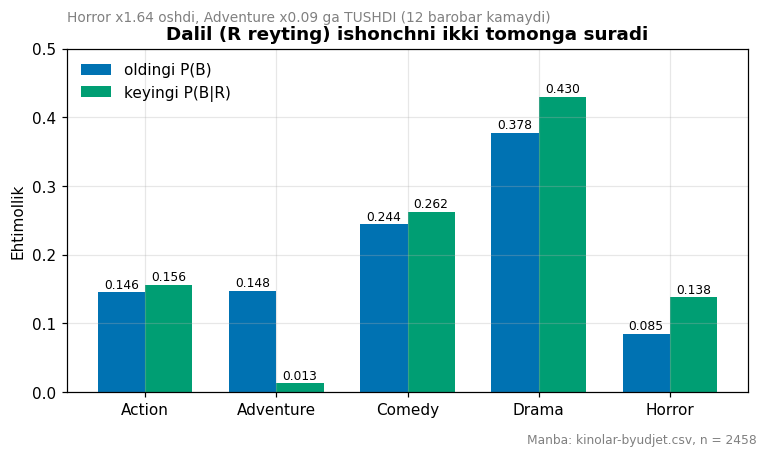

In [12]:
# --- Dalil ishonchni qanday siljitdi? ----------------------------------
x = np.arange(len(nat))
w = 0.36
fig, ax = plt.subplots(figsize=(7, 4.0))
b1 = ax.bar(x - w/2, nat["oldingi"], w, label="oldingi P(B)", color=oiBlue)
b2 = ax.bar(x + w/2, nat["keyingi"], w, label="keyingi P(B|R)", color=oiGreen)
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.006,
                f"{b.get_height():.3f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(nat["bolak"])
ax.set_ylim(0, 0.50)
ax.set_ylabel("Ehtimollik")
ax.set_title("Dalil (R reyting) ishonchni ikki tomonga suradi",
             fontweight="bold")
ax.text(0, 1.08, "Horror x1.64 oshdi, Adventure x0.09 ga TUSHDI (12 barobar kamaydi)",
        transform=ax.transAxes, fontsize=9, color="grey")
ax.legend(loc="upper left", frameon=False)
fig.text(0.99, -0.02, "Manba: kinolar-byudjet.csv, n = 2458",
         ha="right", fontsize=8, color="grey")
plt.tight_layout()
plt.show()

### Natija (kutilayotgan)

```
nazorat sinovi (teng ishonchlilik): keyingi = 0.2000 0.3000 0.5000
oldingi bilan mos: True

    bolak  oldingi  ishonchlilik  keyingi  bevosita   mos   koeff
   Action  0.14565       0.48603  0.15633   0.15633  True 1.07338
Adventure  0.14768       0.03857  0.01258   0.01258  True 0.08517
   Comedy  0.24410       0.48667  0.26235   0.26235  True 1.07478
    Drama  0.37795       0.51561  0.43037   0.43037  True 1.13869
   Horror  0.08462       0.74038  0.13836   0.13836  True 1.63510

dalil P(R) = 0.4528071603
keyingi ehtimolliklar yigʻindisi = 1.0000000000
BARCHA besh janr uchun mos: True

P(H) = 0.0846   P(R|H) = 0.7404   P(R|H^c) = 959/2250 = 0.4262
oldingi shans = 0.092444
ishonchlilik nisbati LR = 1.737086
keyingi shans = 0.160584 -> keyingi ehtimollik = 0.1383647799
```

### Talqin — daftaringizga yozing

**T2.1** Beshta keyingi ehtimollikning yigʻindisi aynan $1$ chiqdi. Bu
tasodifmi? Buni Bayes formulasidan **keltirib chiqaring**.

**T2.2** Adventure uchun koeffitsiyent $0{,}085$: dalil ishonchni qariyb
**12 barobar kamaytirdi**. «Keyingi ehtimollik doim oldingisidan katta»
degan tasavvur nima uchun notoʻgʻri? Koeffitsiyent **qachon** $1$ dan
katta, qachon kichik boʻlishini $\Pr(R\mid B)$ va $\Pr(R)$ orqali
umumiy shaklda yozing.

**T2.3** `bayes()` funksiyasi oldingi ehtimolliklar yigʻindisi $1$
emasligini tekshiradi va **xato beradi**. Nima uchun bu tekshiruv
funksiyaning ichida boʻlishi kerak?

**T2.4** Shanslar shakli «bazaviy stavka» va «dalil kuchi» ni ajratib
koʻrsatadi. Horror uchun LR $= 1{,}737$ — bu «kuchli dalil»mi?
Javobingizni koeffitsiyent $1{,}635$ bilan bogʻlang.

**T2.5** Bevosita sanash **mumkin boʻlgani uchun** biz formulani
tekshira oldik. Keyingi topshiriqda bunday imkoniyat **boʻlmaydi**.
Nima uchun? Bu tekshirilgan formulaga ishonish uchun yetarli asosmi?

### Qaror

Onlayn kinoteatr tavsiya tizimini quradi: foydalanuvchi R reytingli
filmni tomosha qildi. Tizim keyingi qaysi janrni tavsiya qilishi kerak?
$\Pr(B\mid R)$ jadvalidan foydalanib javob bering — **va** bu
tavsiyaning kamida ikkita jiddiy kamchiligini ayting.

---
## 3-topshiriq. Skrining testi kalkulyatori

**Qiyinlik: 4 (Analitik) · Blum: Tahlil · 25 ball · 25 daqiqa**

### Statistik tushuncha

| Atama | Belgi | Maʼnosi |
|---|---|---|
| Tarqalganlik *(prevalence)* | $\Pr(K)$ | aholida kasallarning ulushi — **bazaviy stavka** |
| Sezgirlik *(sensitivity)* | $\Pr(+\mid K)$ | kasallarning qanchasini test topadi |
| Xoslik *(specificity)* | $\Pr(-\mid K^{c})$ | sogʻlomlarning qanchasini test toʻgʻri chiqaradi |
| **Bashoratlovchi qiymat** *(PPV)* | $\Pr(K\mid +)$ | musbat natija olganlarning qanchasi haqiqatan kasal |

**Yoʻnalish masalasi.** Test ishlab chiquvchisi sezgirlik va xoslikni
biladi — u testni *kasal* va *sogʻlom* guruhlarda sinagan. Bemorga esa
PPV kerak. Bu ikkalasi **butunlay boshqa sonlar**, chunki maxrajlari
boshqa. Bayes ular orasidagi koʻprik:

$$\Pr(K \mid +) = \frac{\Pr(+\mid K)\Pr(K)}
{\Pr(+\mid K)\Pr(K) + \Pr(+\mid K^{c})\Pr(K^{c})}.$$

**Bazaviy stavka xatosi** *(base rate fallacy)* — jonli va aniq dalilga
($0{,}99$, $0{,}95$) eʼtibor qaratib, hodisaning umumiy chastotasini
($0{,}001$) eʼtiborsiz qoldirish.

### Maʼlumot

**Bu topshiriqda maʼlumot fayli yoʻq.** Qiymatlar **faraziy** — ular
oʻquv maqsadida tanlangan va hech qanday mamlakat statistikasini
ifodalamaydi:

* tarqalganlik $\Pr(K) = 0{,}001$,
* sezgirlik $\Pr(+\mid K) = 0{,}99$,
* xoslik $\Pr(-\mid K^{c}) = 0{,}95$.

In [13]:
# --- Skrining kalkulyatori ---------------------------------------------
# Bayesni har safar qoʻlda yozish oʻrniga BITTA funksiya.
def skrining(tarqalganlik, sezgirlik, xoslik):
    assert 0 <= tarqalganlik <= 1 and 0 <= sezgirlik <= 1 and 0 <= xoslik <= 1
    yolgon_musbat = 1 - xoslik                       # P(+ | K^c)
    # Maxraj — toʻliq ehtimollik formulasi. Boʻlinma: {K, K^c}.
    P_musbat = sezgirlik * tarqalganlik + \
        yolgon_musbat * (1 - tarqalganlik)
    P_manfiy = 1 - P_musbat
    return {
        "P_musbat": P_musbat,
        "PPV": sezgirlik * tarqalganlik / P_musbat,              # P(K | +)
        "NPV": xoslik * (1 - tarqalganlik) / P_manfiy,           # P(K^c | -)
        "FOR": (1 - sezgirlik) * tarqalganlik / P_manfiy,        # P(K | -)
    }


nat3 = skrining(0.001, 0.99, 0.95)
print("P(+)      = %.5f" % nat3["P_musbat"])
print("PPV = P(K|+)   = %.6f  = %.2f %%" % (nat3["PPV"], 100 * nat3["PPV"]))
print("NPV = P(K^c|-) = %.6f" % nat3["NPV"])
print("P(K|-)         = %.8f" % nat3["FOR"])

P(+)      = 0.05094
PPV = P(K|+)   = 0.019435  = 1.94 %
NPV = P(K^c|-) = 0.999989
P(K|-)         = 0.00001054


In [14]:
# --- Xuddi shu javob CHASTOTA shaklida ---------------------------------
# Gigerenzer va Hoffrage (1995): bir xil masala chastota shaklida
# berilganda odamlar sezilarli darajada yaxshiroq yechadi.
AHOLI = 10000
kasal = AHOLI * 0.001                  # 10
soglom = AHOLI - kasal                 # 9990
kasal_musbat = kasal * 0.99            # 9.9
soglom_musbat = soglom * 0.05          # 499.5
jami_musbat = kasal_musbat + soglom_musbat

print("%d kishilik guruhda:" % AHOLI)
print("  kasal  : %6.1f  -> musbat %6.1f" % (kasal, kasal_musbat))
print("  sogʻlom: %6.1f  -> musbat %6.1f   (yolgʻon musbat)"
      % (soglom, soglom_musbat))
print("  jami musbat: %.1f" % jami_musbat)
print("  haqiqiy kasal ulushi = %.1f/%.1f = %.6f"
      % (kasal_musbat, jami_musbat, kasal_musbat / jami_musbat))
print("formula bilan mos:",
      np.isclose(kasal_musbat / jami_musbat, nat3["PPV"]))

10000 kishilik guruhda:
  kasal  :   10.0  -> musbat    9.9
  sogʻlom: 9990.0  -> musbat  499.5   (yolgʻon musbat)
  jami musbat: 509.4
  haqiqiy kasal ulushi = 9.9/509.4 = 0.019435
formula bilan mos: True


In [15]:
# --- PPV faqat bazaviy stavkaga qanchalik bogʻliq? ---------------------
# TEST OʻZGARMAYDI: sezgirlik 0.99, xoslik 0.95 — barcha qatorlarda
# bir xil. Faqat tarqalganlik oʻzgaradi.
tarqalganliklar = [0.001, 0.01, 0.05, 0.10]
supurma = pd.DataFrame({
    "tarqalganlik": tarqalganliklar,
    "P_musbat": [skrining(t, 0.99, 0.95)["P_musbat"] for t in tarqalganliklar],
    "PPV":      [skrining(t, 0.99, 0.95)["PPV"]      for t in tarqalganliklar],
    "NPV":      [skrining(t, 0.99, 0.95)["NPV"]      for t in tarqalganliklar],
})
supurma["PPV_foiz"] = [f"{100*v:.2f} %" for v in supurma["PPV"]]
print(supurma.to_string(index=False, float_format=lambda v: f"{v:.5f}"))

# PPV = 0.5 boʻladigan tarqalganlik: shanslar shaklidan analitik yechim.
# PPV = 0.5  <=>  oldingi shans x LR+ = 1  <=>  p = 1/(1+LR+)
LR_musbat = 0.99 / 0.05
p_yarim = 1 / (1 + LR_musbat)
print("\nLR+ = %.1f" % LR_musbat)
print("PPV = 0,5 boʻladigan tarqalganlik = 1/(1+LR+) = %.6f" % p_yarim)
print("tekshiruv: PPV(%.6f) = %.6f"
      % (p_yarim, skrining(p_yarim, 0.99, 0.95)["PPV"]))

 tarqalganlik  P_musbat     PPV     NPV PPV_foiz
      0.00100   0.05094 0.01943 0.99999   1.94 %
      0.01000   0.05940 0.16667 0.99989  16.67 %
      0.05000   0.09700 0.51031 0.99945  51.03 %
      0.10000   0.14400 0.68750 0.99883  68.75 %

LR+ = 19.8
PPV = 0,5 boʻladigan tarqalganlik = 1/(1+LR+) = 0.048077
tekshiruv: PPV(0.048077) = 0.500000


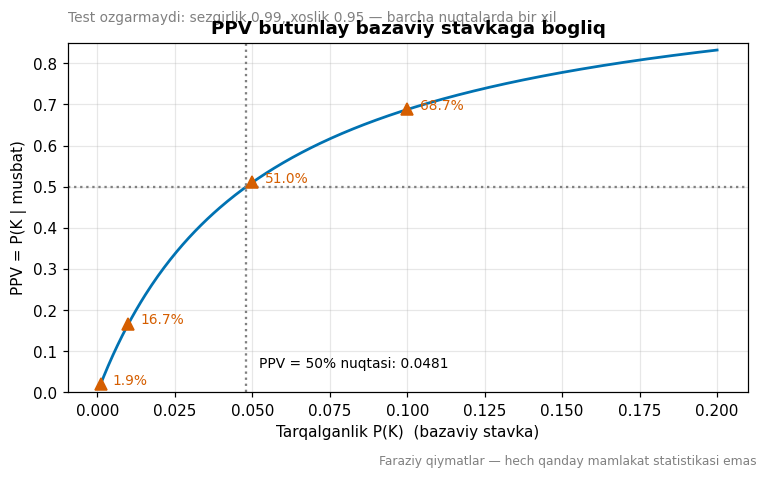

In [16]:
# --- PPV egri chizigʻi -------------------------------------------------
tor = np.linspace(0.0005, 0.20, 400)
ppv_egri = np.array([skrining(t, 0.99, 0.95)["PPV"] for t in tor])

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(tor, ppv_egri, color=oiBlue, lw=1.8)
ax.axhline(0.5, ls=":", color="grey")
ax.axvline(p_yarim, ls=":", color="grey")
ax.plot(supurma["tarqalganlik"], supurma["PPV"], "^",
        color=oiVerm, ms=8, ls="none")
for t, v in zip(supurma["tarqalganlik"], supurma["PPV"]):
    ax.text(t + 0.004, v, f"{100*v:.1f}%", fontsize=9, color=oiVerm)
ax.text(p_yarim + 0.004, 0.06, f"PPV = 50% nuqtasi: {p_yarim:.4f}", fontsize=9)
ax.set_ylim(0, 0.85)
ax.set_xlabel("Tarqalganlik P(K)  (bazaviy stavka)")
ax.set_ylabel("PPV = P(K | musbat)")
ax.set_title("PPV butunlay bazaviy stavkaga bogliq", fontweight="bold")
ax.text(0, 1.06, "Test ozgarmaydi: sezgirlik 0.99, xoslik 0.95 — barcha nuqtalarda bir xil",
        transform=ax.transAxes, fontsize=9, color="grey")
fig.text(0.99, -0.02, "Faraziy qiymatlar — hech qanday mamlakat statistikasi emas",
         ha="right", fontsize=8, color="grey")
plt.tight_layout()
plt.show()

In [17]:
# --- Nima uchun ikki bosqichli skrining ishlaydi? ----------------------
# Ikkinchi bosqichda BAZAVIY STAVKA endi 0.001 emas — u birinchi
# bosqichning KEYINGI ehtimolligi, yaʼni 0.0194.
bosqich1 = skrining(0.001, 0.99, 0.95)
bosqich2 = skrining(bosqich1["PPV"], 0.99, 0.99)   # tasdiqlovchi test

print("1-bosqich: bazaviy stavka %.4f -> PPV %.4f" % (0.001, bosqich1["PPV"]))
print("2-bosqich: bazaviy stavka %.4f -> PPV %.4f"
      % (bosqich1["PPV"], bosqich2["PPV"]))
print("Ikki bosqichdan keyin musbat natijaning %.1f %% i haqiqiy."
      % (100 * bosqich2["PPV"]))

1-bosqich: bazaviy stavka 0.0010 -> PPV 0.0194
2-bosqich: bazaviy stavka 0.0194 -> PPV 0.6624
Ikki bosqichdan keyin musbat natijaning 66.2 % i haqiqiy.


### Natija (kutilayotgan)

```
P(+)      = 0.05094
PPV = P(K|+)   = 0.019435  = 1.94 %
NPV = P(K^c|-) = 0.999989
P(K|-)         = 0.00001054

10000 kishilik guruhda:
  kasal  :   10.0  -> musbat    9.9
  sogʻlom: 9990.0  -> musbat  499.5   (yolgʻon musbat)
  jami musbat: 509.4
  haqiqiy kasal ulushi = 9.9/509.4 = 0.019435
formula bilan mos: True

 tarqalganlik  P_musbat     PPV     NPV PPV_foiz
      0.00100   0.05094 0.01943 0.99999   1.94 %
      0.01000   0.05940 0.16667 0.99989  16.67 %
      0.05000   0.09700 0.51031 0.99945  51.03 %
      0.10000   0.14400 0.68750 0.99883  68.75 %

LR+ = 19.8
PPV = 0,5 boʻladigan tarqalganlik = 1/(1+LR+) = 0.048077
tekshiruv: PPV(0.048077) = 0.500000

1-bosqich: bazaviy stavka 0.0010 -> PPV 0.0194
2-bosqich: bazaviy stavka 0.0194 -> PPV 0.6624
Ikki bosqichdan keyin musbat natijaning 66.2 % i haqiqiy.
```

### Talqin — daftaringizga yozing

**T3.1** «Test $99\,\%$ aniq» degan jumla qaysi sonni nazarda tutadi va
bemor qaysi sonni **eshitadi**? Ikkalasini maxraji bilan yozing. Farq
necha barobar?

**T3.2** $\text{NPV} = 0{,}999989$ — test **rad etishda** ajoyib,
**tasdiqlashda** esa deyarli befoyda. Bu ziddiyat emas. Uni bazaviy
stavka orqali tushuntiring.

**T3.3** PPV $=50\,\%$ nuqtasi $0{,}0481$ ga teng. Bu sonni
$\text{LR}^{+} = 19{,}8$ dan **keltirib chiqaring**. Agar testning
xosligi $0{,}95$ dan $0{,}99$ ga koʻtarilsa, bu nuqta qayerga siljiydi?
Hisoblang.

**T3.4** Ikki bosqichli skriningda PPV $1{,}94\,\%$ dan $66{,}2\,\%$ ga
koʻtarildi — **ikkinchi test birinchisidan kuchliroq boʻlgani
uchunmi**, yoki boshqa sababmi? Aniq javob bering.

**T3.5** Grafikdagi egri chiziq $0$ ga yaqin joyda juda tik. Bu
tiklikning **siyosat uchun** maʼnosi nima?

**T3.6** Barcha qiymatlar **faraziy**. Agar siz haqiqiy siyosat
tavsiyasini yozayotgan boʻlsangiz, qaysi uchta sonni qaysi manbadan
olishingiz kerak edi?

### Qaror

Vazirlik butun aholi uchun majburiy skrining dasturini muhokama
qilmoqda. Sizdan bitta sahifalik xizmat xati soʻralgan. Yuqoridagi
sonlardan foydalanib **tavsiya** yozing (5–7 jumla): dasturni
qoʻllab-quvvatlaysizmi, qanday shart bilan, va qanday muqobil taklif
qilasiz? Yolgʻon musbatlarning inson va moliyaviy narxini oshkora
ayting.

---
## 4-topshiriq. Monty Hall simulyatsiyasi

**Qiyinlik: 5 (Ilgʻor) · Blum: Baholash · 25 ball · 25 daqiqa**

### Statistik tushuncha

Uchta eshik: bittasida avtomobil, ikkitasida echki.

1. Siz bitta eshikni tanlaysiz.
2. Boshlovchi qolgan ikkitadan **echki bor** eshikni ochadi.
3. Tanlovni almashtirasizmi?

**Kalit shart — uni har safar aytish shart.** Boshlovchi avtomobilning
qayerdaligini **biladi** va **doim** echkili eshikni ochadi. Agar u
tasodifan ochsa, javob $1/2$ boʻladi.

**Nazariy javob.** Boshlangʻich tanlov toʻgʻri boʻlish ehtimoli $1/3$;
boshlovchi hech qachon avtomobilni ochmaydi, shu sababli bu ehtimollik
oʻzgarmaydi. Demak qolish yutugʻi $1/3$, almashtirish yutugʻi $2/3$.

**Nima uchun simulyatsiya?** Bu masala intuitsiyaga zid: koʻpchilik
«ikki eshik qoldi — demak 50/50» deydi. Simulyatsiya **bahsni
tugatadi**.

### Maʼlumot — oʻzimiz yaratamiz

**Generator: MINSTD (Lehmer)**, 2-haftadagi bilan *aynan bir xil*:
$$x_{k+1} = (48\,271\,x_k) \bmod 2\,147\,483\,647,\qquad
u_k = x_k / 2\,147\,483\,647 .$$
Urugʻ $= 2026$. Eng katta oraliq koʻpaytma
$48\,271 \times 2\,147\,483\,646 < 2^{53}$, demak u R ning `double`
turida va Pythonning butun sonida **bit darajasida** bir xil
hisoblanadi.

In [18]:
# --- MINSTD generatori (2-haftadan oʻzgarishsiz) -----------------------
class Minstd:
    """Lehmer generatori: x <- (48271 x) mod 2147483647."""

    def __init__(self, urugh):
        self.m = 2147483647
        self.a = 48271
        x = urugh % self.m
        self.x = 1 if x == 0 else x

    def __call__(self, k):
        u = np.empty(k)
        x, a, m = self.x, self.a, self.m
        for i in range(k):
            x = (a * x) % m       # butun sonli arifmetika — aniq
            u[i] = x / m
        self.x = x
        return u


# Nazorat qiymatlari — R daftaridagi sonlar bilan SOLISHTIRING.
for i, v in enumerate(Minstd(2026)(5), start=1):
    print("u[%d] = %.10f" % (i, v))

u[1] = 0.0455402984
u[2] = 0.2757419647
u[3] = 0.3403783731
u[4] = 0.4044473546
u[5] = 0.0782521903


In [19]:
# --- Monty Hall simulyatsiyasi -----------------------------------------
# Eshiklar 0, 1, 2. Har bir oʻyin uchun UCHTA tasodifiy son:
#   u1 -> avtomobil qaysi eshikda
#   u2 -> siz qaysi eshikni tanlaysiz
#   u3 -> boshlovchi TANLOV TOʻGʻRI boʻlgan holatda qaysi echkini ochadi
# Uchinchi son faqat bitta holatda kerak, ammo uni HAR DOIM olamiz —
# shunda sonlar oqimi ikkala tilda aynan bir xil boʻladi.
N = 100000
g = Minstd(2026)
u = g(3 * N)

u1, u2, u3 = u[0::3], u[1::3], u[2::3]
avto = np.floor(u1 * 3).astype(int)
tanlov = np.floor(u2 * 3).astype(int)

# Boshlovchi qaysi eshikni ochadi?
# Holat A (tanlov == avto): qolgan IKKITA eshikda ham echki bor —
#   u3 bilan tanlaydi (0.5 dan kichik boʻlsa kichik raqamlisini).
# Holat B (tanlov != avto): boshlovchining TANLOVI YOʻQ — u yagona
#   qolgan eshikni ochishi shart: 0+1+2 = 3, demak 3 - tanlov - avto.
qolgan1 = np.minimum((tanlov + 1) % 3, (tanlov + 2) % 3)
qolgan2 = np.maximum((tanlov + 1) % 3, (tanlov + 2) % 3)
ochiq = np.where(tanlov == avto,
                 np.where(u3 < 0.5, qolgan1, qolgan2),
                 3 - tanlov - avto)

# Almashtirilgan eshik — uchinchisi.
almash = 3 - tanlov - ochiq

# --- MAJBURIY NAZORAT TEKSHIRUVLARI ------------------------------------
print("(1) boshlovchi hech qachon avtomobilni ochmadi:",
      bool((ochiq != avto).all()))
print("(2) boshlovchi hech qachon sizning eshigingizni ochmadi:",
      bool((ochiq != tanlov).all()))
print("(3) almashtirilgan eshik ochiq ham, tanlangan ham emas:",
      bool(((almash != ochiq) & (almash != tanlov)).all()))

(1) boshlovchi hech qachon avtomobilni ochmadi: True
(2) boshlovchi hech qachon sizning eshigingizni ochmadi: True
(3) almashtirilgan eshik ochiq ham, tanlangan ham emas: True


In [20]:
# --- Natijalar ---------------------------------------------------------
qolish_yutuq = (tanlov == avto)
almash_yutuq = (almash == avto)

print("qolish      : nazariy 1/3 = %.5f   simulyatsiya = %.5f"
      % (1/3, qolish_yutuq.mean()))
print("almashtirish: nazariy 2/3 = %.5f   simulyatsiya = %.5f"
      % (2/3, almash_yutuq.mean()))
print("yigʻindi = %.5f  (1 boʻlishi shart)"
      % (qolish_yutuq.mean() + almash_yutuq.mean()))

# Farqni STANDART XATO birligida oʻlchaymiz.
SE = np.sqrt((2/3) * (1/3) / N)
print("|farq| = %.5f   SE = %.5f   farq/SE = %.2f"
      % (abs(almash_yutuq.mean() - 2/3), SE,
         abs(almash_yutuq.mean() - 2/3) / SE))

qolish      : nazariy 1/3 = 0.33333   simulyatsiya = 0.33294
almashtirish: nazariy 2/3 = 0.66667   simulyatsiya = 0.66706
yigʻindi = 1.00000  (1 boʻlishi shart)
|farq| = 0.00039   SE = 0.00149   farq/SE = 0.26


In [21]:
# --- Yaqinlashish: xato monoton kamaydimi? -----------------------------
kum = np.cumsum(almash_yutuq) / np.arange(1, N + 1)
nlar = [10, 100, 1000, 10000, 100000]
yaq = pd.DataFrame({
    "N": nlar,
    "baho": [kum[k - 1] for k in nlar],
    "xato": [abs(kum[k - 1] - 2/3) for k in nlar],
})
print(yaq.to_string(index=False, float_format=lambda v: f"{v:.5f}"))
print("xato barcha qadamlarda kamaydimi?",
      bool((np.diff(yaq["xato"]) < 0).all()))

     N    baho    xato
    10 0.60000 0.06667
   100 0.65000 0.01667
  1000 0.67100 0.00433
 10000 0.67490 0.00823
100000 0.66706 0.00039
xato barcha qadamlarda kamaydimi? False


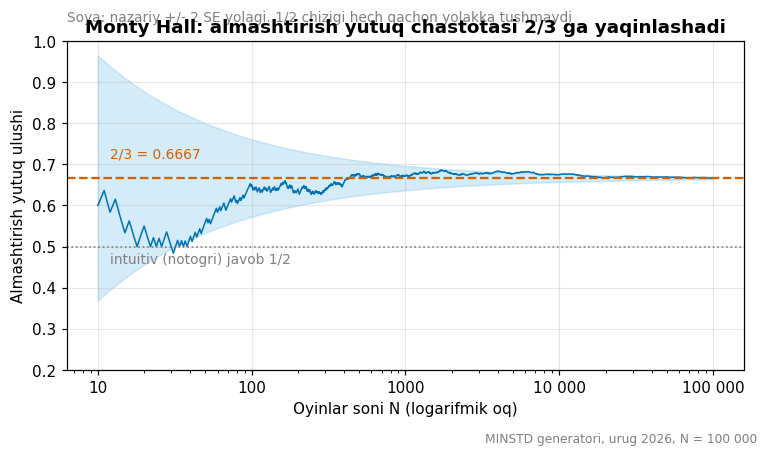

In [22]:
# --- Yaqinlashish grafigi ----------------------------------------------
indeks = np.unique(np.round(
    np.exp(np.linspace(np.log(10), np.log(N), 2500))).astype(int))
past = 2/3 - 2 * np.sqrt((2/3)*(1/3)/indeks)
yuqori = 2/3 + 2 * np.sqrt((2/3)*(1/3)/indeks)

fig, ax = plt.subplots(figsize=(7, 4.0))
ax.fill_between(indeks, past, yuqori, color=oiSky, alpha=0.25)
ax.plot(indeks, kum[indeks - 1], color=oiBlue, lw=1.0)
ax.axhline(2/3, color=oiVerm, lw=1.5, ls="--")
ax.axhline(0.5, color="grey", lw=1.1, ls=":")
ax.text(12, 2/3 + 0.05, "2/3 = 0.6667", color=oiVerm, fontsize=9)
ax.text(12, 0.46, "intuitiv (notogri) javob 1/2", color="grey", fontsize=9)
ax.set_xscale("log")
ax.set_xticks([10, 100, 1000, 10000, 100000])
ax.set_xticklabels(["10", "100", "1000", "10 000", "100 000"])
ax.set_ylim(0.2, 1.0)
ax.set_xlabel("Oyinlar soni N (logarifmik oq)")
ax.set_ylabel("Almashtirish yutuq ulushi")
ax.set_title("Monty Hall: almashtirish yutuq chastotasi 2/3 ga yaqinlashadi",
             fontweight="bold")
ax.text(0, 1.06, "Soya: nazariy +/- 2 SE yolagi. 1/2 chizigi hech qachon yolakka tushmaydi",
        transform=ax.transAxes, fontsize=9, color="grey")
fig.text(0.99, -0.02, "MINSTD generatori, urug 2026, N = 100 000",
         ha="right", fontsize=8, color="grey")
plt.tight_layout()
plt.show()

In [23]:
# --- MUHIM QIYOS: BEXABAR boshlovchi -----------------------------------
# Endi shartni buzamiz: boshlovchi avtomobil qayerdaligini BILMAYDI va
# qolgan ikkitadan birini TASODIFAN ochadi. Agar u avtomobilni ochib
# qoʻysa, oʻyin bekor qilinadi.
g2 = Minstd(4052)        # boshqa urugʻ: 2 x 2026
u_b = g2(3 * N)
avto_b = np.floor(u_b[0::3] * 3).astype(int)
tanlov_b = np.floor(u_b[1::3] * 3).astype(int)
u3_b = u_b[2::3]

q1 = np.minimum((tanlov_b + 1) % 3, (tanlov_b + 2) % 3)
q2 = np.maximum((tanlov_b + 1) % 3, (tanlov_b + 2) % 3)
ochiq_b = np.where(u3_b < 0.5, q1, q2)

bekor = (ochiq_b == avto_b)              # avtomobil ochildi -> bekor
almash_b = 3 - tanlov_b - ochiq_b
print("bekor qilingan raundlar: %d (%.1f %%)" % (bekor.sum(), 100*bekor.mean()))
print("BEXABAR boshlovchi, almashtirish yutugʻi = %.5f  (nazariy 1/2)"
      % (almash_b[~bekor] == avto_b[~bekor]).mean())
print("BILADIGAN boshlovchi, almashtirish yutugʻi = %.5f (nazariy 2/3)"
      % almash_yutuq.mean())
print("Xulosa: farq eshiklarda emas — BOSHLOVCHINING BILIMIDA.")

bekor qilingan raundlar: 33281 (33.3 %)
BEXABAR boshlovchi, almashtirish yutugʻi = 0.50109  (nazariy 1/2)
BILADIGAN boshlovchi, almashtirish yutugʻi = 0.66706 (nazariy 2/3)
Xulosa: farq eshiklarda emas — BOSHLOVCHINING BILIMIDA.


### Natija (kutilayotgan)

```
u[1] = 0.0455402984
u[2] = 0.2757419647
u[3] = 0.3403783731
u[4] = 0.4044473546
u[5] = 0.0782521903

(1) boshlovchi hech qachon avtomobilni ochmadi: True
(2) boshlovchi hech qachon sizning eshigingizni ochmadi: True
(3) almashtirilgan eshik ochiq ham, tanlangan ham emas: True

qolish      : nazariy 1/3 = 0.33333   simulyatsiya = 0.33294
almashtirish: nazariy 2/3 = 0.66667   simulyatsiya = 0.66706
yigʻindi = 1.00000  (1 boʻlishi shart)
|farq| = 0.00039   SE = 0.00149   farq/SE = 0.26

     N    baho    xato
    10 0.60000 0.06667
   100 0.65000 0.01667
  1000 0.67100 0.00433
 10000 0.67490 0.00823
100000 0.66706 0.00039
xato barcha qadamlarda kamaydimi? False

bekor qilingan raundlar: 33281 (33.3 %)
BEXABAR boshlovchi, almashtirish yutugʻi = 0.50109  (nazariy 1/2)
BILADIGAN boshlovchi, almashtirish yutugʻi = 0.66706 (nazariy 2/3)
```

### Talqin — daftaringizga yozing

**T4.1** Simulyatsiya $0{,}66706$ berdi, nazariya $0{,}66667$. Farq
$0{,}00039$ — bu «yaqin»mi? Javobingizni **SE birligida** bering
(farq/SE $= 0{,}26$). Qanday qiymatdan boshlab tashvishlanish kerak?

**T4.2** Nazorat tekshiruvlari (1)–(3) nima uchun **majburiy**? Har biri
qanday xatoni tutadi? Agar (1) `False` chiqqanida, kodning qaysi
qatorini birinchi boʻlib tekshirardingiz?

**T4.3** $N = 1000$ da xato $0{,}0043$, $N = 10\,000$ da $0{,}0082$ —
xato **oshdi**. Katta sonlar qonuni buzildimi? «Yaqinlashish» va
«monoton kamayish» ni aniq ajrating.

**T4.4** Bexabar boshlovchi holatida $33{,}3\,\%$ raund bekor qilindi.
Bu son tasodifmi? Uni nazariy hisoblang.

**T4.5** «Ikki eshik qoldi — demak 50/50» deydigan hamkasbingizga
**Bayes tili bilan** javob yozing (4–5 jumla). *(Maslahat: siz eshik 0
ni tanladingiz va boshlovchi eshik 1 ni ochdi.
$\Pr(\text{ochiq}=1 \mid \text{avto}=0) = 1/2$, ammo
$\Pr(\text{ochiq}=1 \mid \text{avto}=2) = 1$.)*

**T4.6** MINSTD ishlatilgani uchun sizning sonlaringiz R bilan
ishlaydigan talabaning sonlari bilan **aynan** mos tushishi kerak. Bu
mos tushish nimani isbotlaydi va nimani isbotlamaydi?

### Qaror

Telekanal oʻyin koʻrsatuvining qoidalarini oʻzgartirmoqchi: boshlovchi
endi eshikni **tasodifan** ochadi. Prodyuser sizdan soʻraydi: «Bu
tomoshabinlar uchun oʻyinni adolatliroq qiladimi?» Sonlar bilan javob
bering va **qaysi maʼnoda** adolatli/adolatsiz ekanini aniqlang.

---
## 5-topshiriq. Bazaviy stavkani oʻzgartirish

**Qiyinlik: 5 (Ilgʻor) · Blum: Baholash · 20 ball · 20 daqiqa**

### Statistik tushuncha

Bayesda ikkita mustaqil kirish bor: **oldingi ehtimollik** (bazaviy
stavka) va **dalilning kuchi** (ishonchlilik nisbati). Shanslar shaklida
ular koʻpaytma sifatida ajraladi:

$$\underbrace{\frac{\Pr(D\mid \text{bayroq})}{\Pr(D^{c}\mid \text{bayroq})}}
_{\text{keyingi shans}}
\;=\;
\underbrace{\frac{\Pr(D)}{\Pr(D^{c})}}_{\text{oldingi shans}}
\;\times\;
\underbrace{\frac{\Pr(\text{bayroq}\mid D)}{\Pr(\text{bayroq}\mid D^{c})}}
_{\text{ishonchlilik nisbati } \mathrm{LR}^{+}} .$$

Bu yozuv haftaning eng muhim xulosasini koʻrsatadi: **modelni
oʻzgartirmasdan** ham keyingi ehtimollikni butunlay oʻzgartirish
mumkin — buning uchun faqat bazaviy stavka oʻzgarishi kifoya.

### Maʼlumot

**Faraziy bank modeli** (real bank maʼlumoti emas):
$\Pr(\text{bayroq}\mid D) = 0{,}90$, $\Pr(\text{bayroq}\mid D^{c}) =
0{,}10$. Defolt bazaviy stavkasi $\Pr(D)$ **portfeldan portfelga
oʻzgaradi** — aynan shuni oʻrganamiz.

In [24]:
# --- Kredit skoring: 3-topshiriqdagi funksiyani QAYTA ISHLATAMIZ -------
# skrining(tarqalganlik, sezgirlik, xoslik) — matematik jihatdan bir xil
# masala, faqat atamalar boshqa:
#   tarqalganlik <-> defolt bazaviy stavkasi P(D)
#   sezgirlik    <-> P(bayroq | D)         = 0.90
#   xoslik       <-> P(bayroq yoʻq | D^c)  = 1 - 0.10 = 0.90
SEZGIRLIK, XOSLIK = 0.90, 0.90

asosiy = skrining(0.03, SEZGIRLIK, XOSLIK)
print("P(D) = 0.03:")
print("  P(bayroq)          = %.4f" % asosiy["P_musbat"])
print("  P(D | bayroq)      = %.6f  (%.2f %%)"
      % (asosiy["PPV"], 100 * asosiy["PPV"]))
print("  yolgʻon bayroqlar  = %.2f %%" % (100 * (1 - asosiy["PPV"])))
print("  P(D | bayroq yoʻq) = %.6f" % asosiy["FOR"])

P(D) = 0.03:
  P(bayroq)          = 0.1240
  P(D | bayroq)      = 0.217742  (21.77 %)
  yolgʻon bayroqlar  = 78.23 %
  P(D | bayroq yoʻq) = 0.003425


In [25]:
# --- BAZAVIY STAVKANI OʻZGARTIRAMIZ ------------------------------------
# Model butunlay oʻzgarmaydi. Faqat portfel tarkibi oʻzgaradi.
stavkalar = [0.01, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30]
kredit = pd.DataFrame({
    "P_D": stavkalar,
    "P_bayroq":   [skrining(p, SEZGIRLIK, XOSLIK)["P_musbat"] for p in stavkalar],
    "P_D_bayroq": [skrining(p, SEZGIRLIK, XOSLIK)["PPV"]      for p in stavkalar],
    "P_D_yoq":    [skrining(p, SEZGIRLIK, XOSLIK)["FOR"]      for p in stavkalar],
})
kredit["koeff"] = kredit["P_D_bayroq"] / kredit["P_D"]
print(kredit.to_string(index=False, float_format=lambda v: f"{v:.5f}"))

LR_kredit = SEZGIRLIK / (1 - XOSLIK)
print("\nLR+ = %.1f  (bu son BARCHA qatorlarda bir xil)" % LR_kredit)
print("P(D|bayroq) = 0,5 boʻladigan bazaviy stavka = 1/(1+LR+) = %.4f"
      % (1 / (1 + LR_kredit)))

    P_D  P_bayroq  P_D_bayroq  P_D_yoq   koeff
0.01000   0.10800     0.08333  0.00112 8.33333
0.03000   0.12400     0.21774  0.00342 7.25806
0.05000   0.14000     0.32143  0.00581 6.42857
0.10000   0.18000     0.50000  0.01220 5.00000
0.15000   0.22000     0.61364  0.01923 4.09091
0.20000   0.26000     0.69231  0.02703 3.46154
0.30000   0.34000     0.79412  0.04545 2.64706

LR+ = 9.0  (bu son BARCHA qatorlarda bir xil)
P(D|bayroq) = 0,5 boʻladigan bazaviy stavka = 1/(1+LR+) = 0.1000


In [26]:
# --- Shanslar shakli: koʻpaytma sifatida qarash ------------------------
# LR ustuni OʻZGARMAYDI — bu «dalil kuchi». Oʻzgarayotgani — oldingi
# shans, yaʼni BAZAVIY STAVKA.
shans = pd.DataFrame({"P_D": stavkalar})
shans["oldingi_shans"] = shans["P_D"] / (1 - shans["P_D"])
shans["LR"] = LR_kredit
shans["keyingi_shans"] = shans["oldingi_shans"] * shans["LR"]
shans["keyingi_ehtimollik"] = shans["keyingi_shans"] / (1 + shans["keyingi_shans"])
print(shans.to_string(index=False, float_format=lambda v: f"{v:.5f}"))

print("PPV jadvali bilan mos:",
      np.allclose(shans["keyingi_ehtimollik"], kredit["P_D_bayroq"]))

    P_D  oldingi_shans      LR  keyingi_shans  keyingi_ehtimollik
0.01000        0.01010 9.00000        0.09091             0.08333
0.03000        0.03093 9.00000        0.27835             0.21774
0.05000        0.05263 9.00000        0.47368             0.32143
0.10000        0.11111 9.00000        1.00000             0.50000
0.15000        0.17647 9.00000        1.58824             0.61364
0.20000        0.25000 9.00000        2.25000             0.69231
0.30000        0.42857 9.00000        3.85714             0.79412
PPV jadvali bilan mos: True


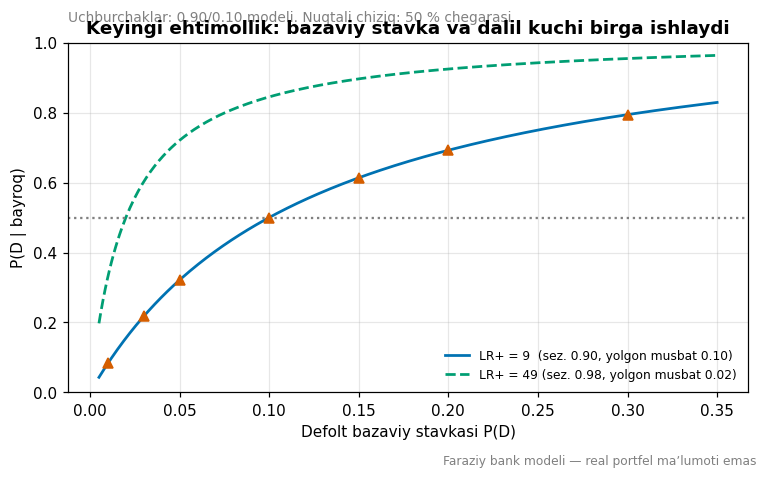

In [27]:
# --- Ikki egri chiziq: kuchli va zaif model ----------------------------
tor5 = np.linspace(0.005, 0.35, 300)
egri_zaif = np.array([skrining(p, 0.90, 0.90)["PPV"] for p in tor5])
egri_kuchli = np.array([skrining(p, 0.98, 0.98)["PPV"] for p in tor5])

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(tor5, egri_zaif, color=oiBlue, lw=1.8,
        label="LR+ = 9  (sez. 0.90, yolgon musbat 0.10)")
ax.plot(tor5, egri_kuchli, color=oiGreen, lw=1.8, ls="--",
        label="LR+ = 49 (sez. 0.98, yolgon musbat 0.02)")
ax.axhline(0.5, ls=":", color="grey")
ax.plot(kredit["P_D"], kredit["P_D_bayroq"], "^", color=oiVerm,
        ms=7, ls="none")
ax.set_ylim(0, 1)
ax.set_xlabel("Defolt bazaviy stavkasi P(D)")
ax.set_ylabel("P(D | bayroq)")
ax.set_title("Keyingi ehtimollik: bazaviy stavka va dalil kuchi birga ishlaydi",
             fontweight="bold")
ax.text(0, 1.06, "Uchburchaklar: 0.90/0.10 modeli. Nuqtali chiziq: 50 % chegarasi",
        transform=ax.transAxes, fontsize=9, color="grey")
ax.legend(loc="lower right", frameon=False, fontsize=8)
fig.text(0.99, -0.02, "Faraziy bank modeli — real portfel maʼlumoti emas",
         ha="right", fontsize=8, color="grey")
plt.tight_layout()
plt.show()

In [28]:
# --- Xuddi shu gʻoya KINO maʼlumotida ----------------------------------
# 2-topshiriqdagi Horror natijasini shanslar shaklida qayta yozamiz.
# DIQQAT: P(R|Horror) va P(R|Horror^c) OʻZGARMAYDI deb faraz qilamiz.
# Birinchi qatorda YAXLITLANMAGAN P_H ni ishlatamiz: yaxlitlangan
# 0.0846 yozilsa, natija 0.138331 chiqadi — haqiqiy 0.138365 emas.
LR_kino = P_R_H / P_R_notH
stsen = pd.DataFrame({"P_Horror": [P_H, 0.15, 0.25, 0.40]})
stsen["oldingi_shans"] = stsen["P_Horror"] / (1 - stsen["P_Horror"])
stsen["keyingi_shans"] = stsen["oldingi_shans"] * LR_kino
stsen["P_Horror_R"] = stsen["keyingi_shans"] / (1 + stsen["keyingi_shans"])
print(stsen.to_string(index=False, float_format=lambda v: f"{v:.5f}"))
print("\nLR = %.4f — dalil kuchi barcha stsenariyda bir xil." % LR_kino)
print("Birinchi qator haqiqiy maʼlumotdan: %.6f" % stsen["P_Horror_R"][0])

 P_Horror  oldingi_shans  keyingi_shans  P_Horror_R
  0.08462        0.09244        0.16058     0.13836
  0.15000        0.17647        0.30654     0.23462
  0.25000        0.33333        0.57903     0.36670
  0.40000        0.66667        1.15806     0.53662

LR = 1.7371 — dalil kuchi barcha stsenariyda bir xil.
Birinchi qator haqiqiy maʼlumotdan: 0.138365


### Natija (kutilayotgan)

```
P(D) = 0.03:
  P(bayroq)          = 0.1240
  P(D | bayroq)      = 0.217742  (21.77 %)
  yolgʻon bayroqlar  = 78.23 %
  P(D | bayroq yoʻq) = 0.003425

    P_D  P_bayroq  P_D_bayroq  P_D_yoq   koeff
0.01000   0.10800     0.08333  0.00112 8.33333
0.03000   0.12400     0.21774  0.00342 7.25806
0.05000   0.14000     0.32143  0.00581 6.42857
0.10000   0.18000     0.50000  0.01220 5.00000
0.15000   0.22000     0.61364  0.01923 4.09091
0.20000   0.26000     0.69231  0.02703 3.46154
0.30000   0.34000     0.79412  0.04545 2.64706

LR+ = 9.0  (bu son BARCHA qatorlarda bir xil)
P(D|bayroq) = 0,5 boʻladigan bazaviy stavka = 1/(1+LR+) = 0.1000

    P_D  oldingi_shans      LR  keyingi_shans  keyingi_ehtimollik
0.01000        0.01010 9.00000        0.09091             0.08333
0.03000        0.03093 9.00000        0.27835             0.21774
0.05000        0.05263 9.00000        0.47368             0.32143
0.10000        0.11111 9.00000        1.00000             0.50000
0.15000        0.17647 9.00000        1.58824             0.61364
0.20000        0.25000 9.00000        2.25000             0.69231
0.30000        0.42857 9.00000        3.85714             0.79412
PPV jadvali bilan mos: True

 P_Horror  oldingi_shans  keyingi_shans  P_Horror_R
  0.08462        0.09244        0.16058     0.13836
  0.15000        0.17647        0.30654     0.23462
  0.25000        0.33333        0.57903     0.36670
  0.40000        0.66667        1.15806     0.53662

LR = 1.7371 — dalil kuchi barcha stsenariyda bir xil.
Birinchi qator haqiqiy maʼlumotdan: 0.138365
```

### Talqin — daftaringizga yozing

**T5.1** `koeff` ustuni bazaviy stavka oshgan sari **kamayadi**
($8{,}33 \to 2{,}65$), garchi keyingi ehtimollik oshsa ham. Bu ziddiyat
emas. Nima uchun?

**T5.2** $\Pr(D) = 0{,}10$ da bayroqlarning aynan yarmi haqiqiy. Bu
sonni $\text{LR}^{+} = 9$ dan **hisoblab** chiqaring va nima uchun bu
«aylanish nuqtasi» ekanini tushuntiring.

**T5.3** Ikki bank: A portfelida $\Pr(D) = 0{,}03$, B portfelida
$\Pr(D) = 0{,}20$. **Bir xil model** ishlatiladi. Bayroq qoʻyilgan
mijozga munosabat ikki bankda bir xil boʻlishi kerakmi? Sonlar bilan
javob bering.

**T5.4** Texnik direktor: «Modelni yaxshilaymiz — sezgirlikni $0{,}90$
dan $0{,}98$ ga koʻtaramiz». Grafikdan foydalanib, bu $\Pr(D) = 0{,}03$
da PPV ni qanchaga koʻtarishini ayting. **Muqobil taklif**: portfelni
bazaviy stavkasi yuqori boʻlgan segmentga toraytirish. Qaysi biri
arzonroq?

**T5.5** Kino stsenariylarida $\Pr(\text{Horror}) = 0{,}40$ boʻlsa,
$\Pr(\text{Horror}\mid R) = 0{,}537$ chiqadi — dalil **bir xil** boʻlsa
ham. «$R$ reyting — Horrorning kuchli belgisi» degan jumlani tuzating.

**T5.6** Etik savol. Agar bazaviy stavka ijtimoiy guruhlar boʻyicha
farq qilsa, **bir xil model** turli guruhlarga turlicha taʼsir qiladi.
Buni jadval bilan koʻrsating va bitta yumshatuvchi chora taklif qiling.

### Qaror

Bank kengashi qaror qabul qilmoqda: bayroq qoʻyilgan barcha arizalarni
avtomatik rad etish. $\Pr(D) = 0{,}03$ boʻlgan portfelda $10\,000$ ariza
uchun **nechta yaxshi mijoz yoʻqotiladi** va **nechta defolt oldi
olinadi**? Ikkala sonni hisoblang. Qarorni qoʻllab-quvvatlaysizmi?

---
## 6-topshiriq (ixtiyoriy, +5 bonus ball). Hosildorlik maʼlumotida Bayes

**Qiyinlik: 6 (Tadqiqotga yoʻnaltirilgan) · Blum: Yaratish · uyda**

Bir xil apparat — butunlay boshqa soha. Fazo: $135$ ta *mamlakat–yil*
kuzatuvi. Boʻlinma — **beshta mamlakat**. Hodisa $Y$ = «bugʻdoy
hosildorligi mintaqa medianasidan yuqori».

In [29]:
hos = pd.read_csv("data/markaziy-osiyo-hosildorlik.csv", encoding="utf-8")

# --- LOKAL TUZOGʻI (2-haftadan eslatma) --------------------------------
# Nomni fayldan OLIB kelamiz — literal yozmaymiz.
mamlakatlar = sorted(hos["mamlakat"].unique())
print(mamlakatlar)
uz = mamlakatlar[0]                                # alifbo tartibida birinchisi
assert (hos["mamlakat"] == uz).sum() == 27, "nom mos kelmadi"

mediana = hos["bugdoy"].median()
Y = hos["bugdoy"] > mediana

oldingi_m = np.array([(hos["mamlakat"] == m).mean() for m in mamlakatlar])
ishonch_m = np.array([Y[hos["mamlakat"] == m].mean() for m in mamlakatlar])
nat6 = bayes(oldingi_m, ishonch_m, mamlakatlar)
nat6["bevosita"] = [((hos["mamlakat"] == m) & Y).sum() / Y.sum()
                    for m in mamlakatlar]
nat6["mos"] = np.abs(nat6["keyingi"] - nat6["bevosita"]) < 1e-12

print("mintaqa bugʻdoy medianasi = %.3f t/ga" % mediana)
print(nat6[["bolak", "oldingi", "ishonchlilik", "keyingi", "bevosita", "mos"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\ndalil P(Y) = %.10f   bevosita = %.10f" % (nat6["dalil"][0], Y.mean()))

['Oʻzbekiston', 'Qirgʻiziston', 'Qozogʻiston', 'Tojikiston', 'Turkmaniston']
mintaqa bugʻdoy medianasi = 1.997 t/ga
       bolak  oldingi  ishonchlilik  keyingi  bevosita  mos
 Oʻzbekiston   0.2000        0.8889   0.3582    0.3582 True
Qirgʻiziston   0.2000        0.8148   0.3284    0.3284 True
 Qozogʻiston   0.2000        0.0000   0.0000    0.0000 True
  Tojikiston   0.2000        0.4074   0.1642    0.1642 True
Turkmaniston   0.2000        0.3704   0.1493    0.1493 True

dalil P(Y) = 0.4962962963   bevosita = 0.4962962963


### Talqin va qaror

**T6.1** $\Pr(U\mid Y) = 0{,}3582$ va $\Pr(Y\mid U) = 0{,}8889$. Ikki
jumla yozing, har birida shu sonlardan bittasi toʻgʻri ishlatilsin.

**T6.2** Qozogʻiston uchun $\Pr(Y\mid \text{Qoz}) = 0$, demak keyingi
ehtimollik ham $0$. Bayes teoremasi bu yerda nima deydi va bu
xulosaning **cheklovi** nimada?

**T6.3** Kuzatuv birligi — *mamlakat–yil*. Bir mamlakatning ketma-ket
yillari bogʻliq. Bu «boʻlinma» shartini buzadimi yoki «teng
imkoniyatlilik» farazini? Farqni aniq koʻrsating.

**T6.4** Mediana **butun mintaqa** boʻyicha olindi. Agar u har bir
mamlakat ichida alohida olinganida, $\Pr(U\mid Y)$ qanday boʻlardi?

**Qaror.** Xalqaro tashkilot mintaqada bugʻdoy dasturi uchun mamlakat
tanlamoqda va sizdan «qaysi mamlakat yuqori hosildorlik bilan koʻproq
bogʻlangan» degan savolga javob soʻraydi. Qaysi ehtimollikni
hisoblaysiz va nima uchun? Sababiy xulosaning chegarasini oshkora
ayting.

---
## Yakuniy nazorat roʻyxati

In [30]:
# Barcha asosiy natijalarni bitta jadvalda yigʻamiz.
xulosa = pd.DataFrame({
    "korsatkich": [
        "n = |S|",
        "P(R) toʻliq ehtimollik formulasi",
        "P(R) bevosita sanash",
        "P(Horror | R)  Bayes",
        "P(Adventure | R)",
        "P(Drama | R)",
        "LR(Horror)",
        "PPV, tarqalganlik 0.001",
        "PPV, tarqalganlik 0.05",
        "PPV = 0.5 nuqtasi (skrining)",
        "Monty Hall: almashtirish",
        "Monty Hall: qolish",
        "P(D | bayroq), P(D) = 0.03",
        "P(D|bayroq) = 0.5 nuqtasi",
        "P(Oʻzbekiston | Y)",
    ],
    "qiymat": [
        n,
        round(P_R_formula, 4), round(float(P_R_bevosita), 4),
        round(float(nat.loc[nat["bolak"] == "Horror", "keyingi"].iloc[0]), 4),
        round(float(nat.loc[nat["bolak"] == "Adventure", "keyingi"].iloc[0]), 4),
        round(float(nat.loc[nat["bolak"] == "Drama", "keyingi"].iloc[0]), 4),
        round(LR, 4),
        round(nat3["PPV"], 4),
        round(skrining(0.05, 0.99, 0.95)["PPV"], 4),
        round(p_yarim, 4),
        round(almash_yutuq.mean(), 5),
        round(qolish_yutuq.mean(), 5),
        round(asosiy["PPV"], 4),
        round(1 / (1 + LR_kredit), 4),
        round(float(nat6["keyingi"][0]), 4),
    ],
})
print(xulosa.to_string(index=False))

                      korsatkich     qiymat
                         n = |S| 2458.00000
P(R) toʻliq ehtimollik formulasi    0.45280
            P(R) bevosita sanash    0.45280
            P(Horror | R)  Bayes    0.13840
                P(Adventure | R)    0.01260
                    P(Drama | R)    0.43040
                      LR(Horror)    1.73710
         PPV, tarqalganlik 0.001    0.01940
          PPV, tarqalganlik 0.05    0.51030
    PPV = 0.5 nuqtasi (skrining)    0.04810
        Monty Hall: almashtirish    0.66706
              Monty Hall: qolish    0.33294
      P(D | bayroq), P(D) = 0.03    0.21770
       P(D|bayroq) = 0.5 nuqtasi    0.10000
              P(Oʻzbekiston | Y)    0.35820


**Kutilayotgan qiymatlar:** 2458 · 0.4528 · 0.4528 · 0.1384 · 0.0126 ·
0.4304 · 1.7371 · 0.0194 · 0.5103 · 0.0481 · 0.66706 · 0.33294 · 0.2177 ·
0.1000 · 0.3582

**Bitta ham son farq qilmasligi kerak** — R va Python daftarlari uchun
ham.

---

## Refleksiya (topshiriq bilan birga topshiriladi)

Har biriga **3–4 jumla** bilan javob bering.

1. **Tekshirilgan formula.** Bayes teoremasini avval javob maʼlum
   boʻlgan joyda sinadik, keyin javob nomaʼlum boʻlgan joyda
   qoʻlladik. Bu ketma-ketlik nima uchun muhim? Agar biz teskarisini
   qilganimizda, qanday xavf paydo boʻlardi?
2. **Yoʻnalish.** Bugun $\Pr(A\mid B)$ va $\Pr(B\mid A)$ farqi uch
   sohada koʻrindi: kino, tibbiyot, kredit. Qaysi biri sizga eng
   ishonarli tuyuldi? Kundalik hayotingizdan **oʻzingizning**
   misolingizni keltiring.
3. **Bazaviy stavka.** «Test $99\,\%$ aniq» degan jumlani eshitganda
   endi qanday savol berasiz? Aynan bitta savolni yozing.
4. **Simulyatsiya va nazariya.** Monty Hall masalasida siz avval qaysi
   javobga ishondingiz? Simulyatsiya fikringizni oʻzgartirdimi, yoki
   nazariy dalil? Bu sizning oʻrganish uslubingiz haqida nima deydi?
5. **Funksiya yozish.** `bayes()` va `skrining()` funksiyalari beshta
   turli masalada ishlatildi. Kodni funksiyaga aylantirish qanday
   xatolardan himoya qildi? Qaysi tekshiruvni siz oʻzingiz qoʻshgan
   boʻlardingiz?

---

## Topshirish tartibi va akademik halollik

* **Fayl:** bajarilgan `W03-lab-<familiya>.ipynb`.
* **Kod xatosiz ishlashi shart:** *Kernel → Restart & Run All* dan soʻng
  hech bir katak xato bermasligi kerak.
* **Talqin va qaror** har bir topshiriq uchun matn koʻrinishida
  yozilgan boʻlishi shart. Faqat kod — bajarilmagan ish.
* **Muddat:** laboratoriyadan keyingi 48 soat ichida, Moodle.
* **Grafiklar:** faqat Okabe–Ito ranglari; maʼnoni faqat rang bilan
  bermang; oʻq nomlari, oʻlchov birligi va manba koʻrsatilsin.
* **Sonlar:** matnda oʻnli ajratgich — **vergul** ($0{,}1384$); kod
  natijasida — **nuqta** (`0.1384`). Aralashtirmang.
* **Faraziy qiymatlar:** skrining va kredit bloklaridagi barcha sonlar
  **faraziy**. Hisobotda ularni rasmiy statistika sifatida keltirish —
  akademik halollik buzilishi.
* **Urugʻ:** har bir simulyatsiya natijasi yonida urugʻ (2026) va
  generator nomi (MINSTD) yozilishi shart.

**Sunʼiy intellekt.** Ruxsat etiladi: kod xatosini topish, funksiya
hujjatini tushuntirish, matnni tahrirlash. **Mumkin emas:** talqin va
qaror bosqichlarini SIʼ ga yozdirish.

> **Alohida ogohlantirish.** Til modellari Bayes masalalarida muntazam
> ravishda **shartni teskari qoʻyadi** ($\Pr(+\mid K)$ ni
> $\Pr(K\mid +)$ deb beradi) va **bazaviy stavkani unutadi**. Har
> qanday javobni oʻz jadvalingizdagi sonlar bilan tekshiring.